# Post-process charge data

## Install and import packages

In [1]:
!pip install --upgrade seaborn
!pip install plotly

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns

## Utils

In [3]:
# Set REASSIGN_CHARGE_MODE to True, in order to have a similar behaviour with the original dataset
REASSIGN_CHARGE_MODE = False

In [4]:
# Set SAVE equals to True, in order to Save cleaned charge data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__charge_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [5]:
# Load charge data
#charge_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 1200
charge_data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             600 non-null    int64  
 1   charge_mode       600 non-null    int64  
 2   duration_minutes  600 non-null    float64
 3   km_driven         600 non-null    float64
 4   charge            600 non-null    float64
 5   id                600 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 28.3 KB


In [6]:
charge_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,1,360,145.836168,5.445394,20.496397,0
1,1,120,344.177535,1.896106,8.824690,13
2,1,360,40.005448,1.899625,29.492113,15
3,1,240,235.781849,1.761355,6.161590,16
4,1,120,407.617192,4.104306,6.262610,19
5,1,360,89.855164,5.678345,30.229940,20
6,1,360,25.753678,3.332298,38.205869,21
7,1,0,255.709776,3.841241,6.343021,28
8,1,360,224.345868,5.392642,19.011842,30
9,1,360,75.755915,3.526162,26.646615,31


### Data description

In [7]:
# Remove duplicates
init_len = len(charge_data)
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(charge_data)}")

Number of duplicates removed: 0


In [8]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Records with missing values:\n")

records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

🔍 Records with missing values:



In [9]:
# main statistics of the dataset
charge_data['delta_soc'] = charge_data['charge']
print("Statistics of the dataset:")
charge_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,600.0,3.149919,1.519017,1.474878,2.048577,2.610340,3.780307,9.836603
delta_soc,600.0,13.406456,9.989672,3.526500,6.952068,8.726426,16.023858,39.001733


In [10]:
# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print('Statistics before post-processing')
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics before post-processing

🔋 Statistics on charge:
 count    600.000000
mean      13.406456
std        9.989672
min        3.526500
25%        6.952068
50%        8.726426
75%       16.023858
max       39.001733
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count    600.000000
mean      33.305981
std       24.234335
min        0.403406
25%        6.543311
50%       36.643900
75%       49.252409
max      116.237765
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    600.000000
mean       0.217167
std        0.413538
min        0.008603
25%        0.020304
50%        0.027290
75%        0.152834
max        2.478891
Name: charge_per_min, dtype: float64


In [11]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [12]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [13]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['charge'] == 0) & (charge_data['km_driven'] == 0) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [14]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [15]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['charge'] == 0) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
stationary_records.head(length)

Number of stationary rows: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [16]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [17]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['charge'] < 0)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [18]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [19]:
# Identify records with high charge per minute
###########################
MAX_CHARGE_PER_MIN = 1.10 #
###########################


anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]

length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 39


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
6,1,360,25.753678,3.332298,38.205869,21,38.205869,0.674076,1.483511
18,1,360,16.570861,2.442913,38.955270,64,38.955270,0.425382,2.350830
19,1,360,15.577252,2.579944,38.614305,65,38.614305,0.403406,2.478891
33,1,360,25.271744,2.107380,32.611063,114,32.611063,0.774944,1.290416
42,1,360,28.009688,3.956228,36.751557,148,36.751557,0.762136,1.312102
59,1,360,26.627704,2.230461,34.548677,196,34.548677,0.770730,1.297471
70,1,360,18.980654,2.990097,36.120080,225,36.120080,0.525488,1.902994
77,1,360,26.134442,2.577426,33.380573,244,33.380573,0.782924,1.277264
79,1,360,30.114832,3.397510,36.143412,258,36.143412,0.833204,1.200186
90,1,360,27.893324,3.186460,34.676218,284,34.676218,0.804393,1.243173


In [20]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [21]:
######################################## TODO: ADD A MAX FOR min_per_perc_of_battery ########################################

In [22]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    561 non-null    int64  
 1   charge_mode              561 non-null    int64  
 2   duration_minutes         561 non-null    float64
 3   km_driven                561 non-null    float64
 4   charge                   561 non-null    float64
 5   id                       561 non-null    int64  
 6   delta_soc                561 non-null    float64
 7   min_per_perc_of_battery  561 non-null    float64
 8   charge_per_min           561 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 39.6 KB


In [23]:
#Print statistics
print('Statistics after post-processing')
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics after post-processing

🔋 Statistics on charge:
 count    561.000000
mean      11.849603
std        8.309648
min        3.526500
25%        6.832527
50%        8.494667
75%       11.693945
max       36.948560
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count    561.000000
mean      35.572886
std       23.430808
min        0.923307
25%       14.419032
50%       38.032525
75%       50.367913
max      116.237765
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    561.000000
mean       0.128273
std        0.230366
min        0.008603
25%        0.019854
50%        0.026293
75%        0.069353
max        1.083063
Name: charge_per_min, dtype: float64


### Charge_mode re-assignment

In [24]:
if REASSIGN_CHARGE_MODE:
    # Print max charge_data_original['charge_per_min'] when '120' is in charge_data_original['charge_mode'], when '240' is in charge_mode and when 'DC' is in chrge_mode
    result = charge_data.groupby("charge_mode")["charge_per_min"].max()
    print(result)

In [25]:
if REASSIGN_CHARGE_MODE:
    # ORIGINAL Thresholds
    max_120 = 0.04
    max_240 = 0.30
    
    
    # Conditions
    conditions = [
        charge_data['charge_per_min'] <= max_120,
        (charge_data['charge_per_min'] > max_120) & (charge_data['charge_per_min'] <= max_240)
    ]
    
    # Values to assign
    values = [120, 240]
    
    # Default value if none of the conditions match
    charge_data['charge_mode'] = np.select(conditions, values, default=360)
    
    charge_data.head(30)

## Data Visualization and Comparative Analysis

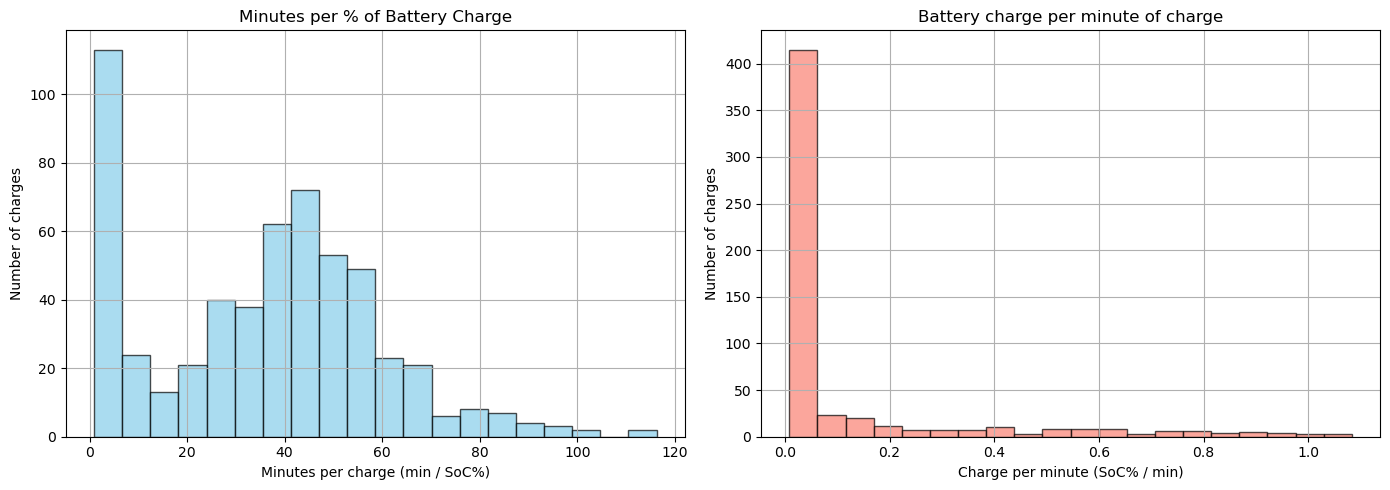

In [26]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
0,1,360,145.836168,5.445394,20.496397,0,20.496397,7.115210,0.140544
1,1,120,344.177535,1.896106,8.824690,13,8.824690,39.001657,0.025640
2,1,360,40.005448,1.899625,29.492113,15,29.492113,1.356480,0.737202
3,1,240,235.781849,1.761355,6.161590,16,6.161590,38.266400,0.026133
4,1,120,407.617192,4.104306,6.262610,19,6.262610,65.087432,0.015364


In [28]:
max_min = charge_data['min_per_perc_of_battery'].max()
max_min_row = charge_data[charge_data['min_per_perc_of_battery'] == max_min]

print("\n Record with maximum min/SoC:\n")
max_min_row.head()


 Record with maximum min/SoC:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
469,1,120,619.066645,6.411707,5.325865,1489,5.325865,116.237765,0.008603


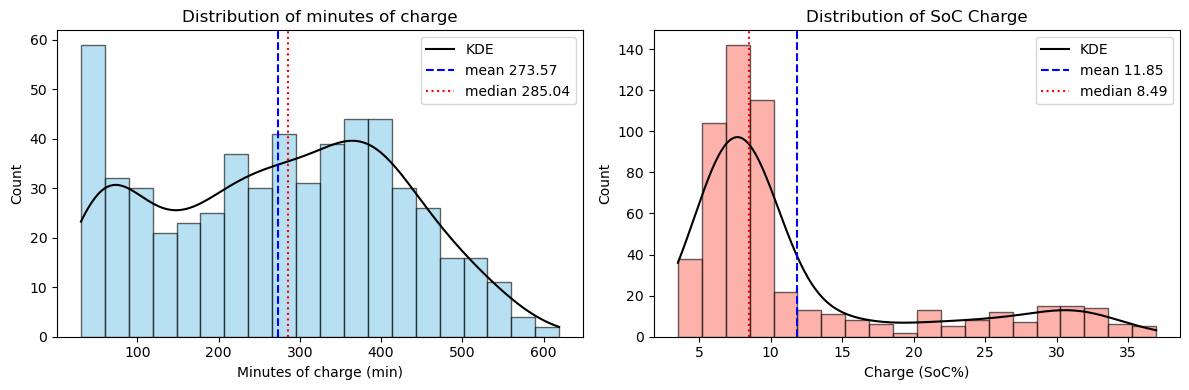

In [29]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Charge', xlabel='Charge (SoC%)')

plt.tight_layout()
plt.show()

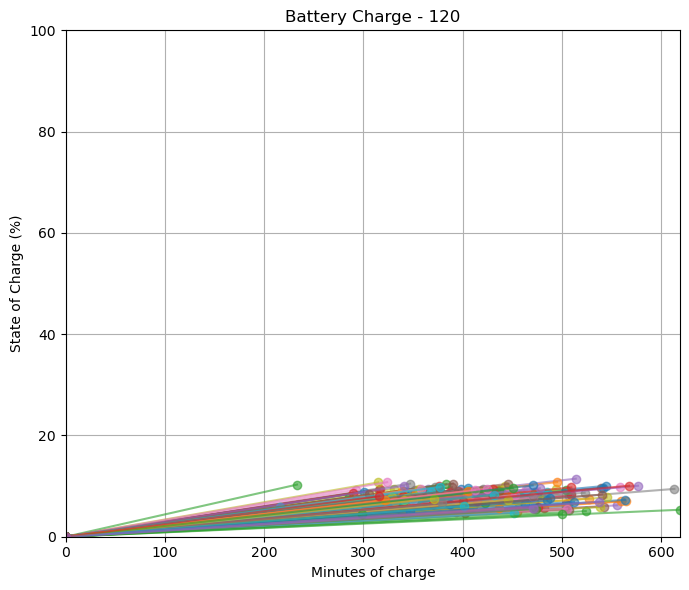

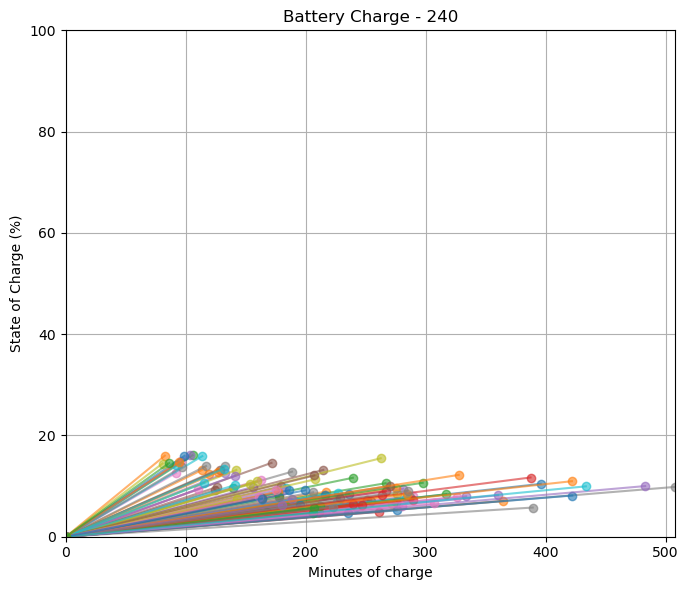

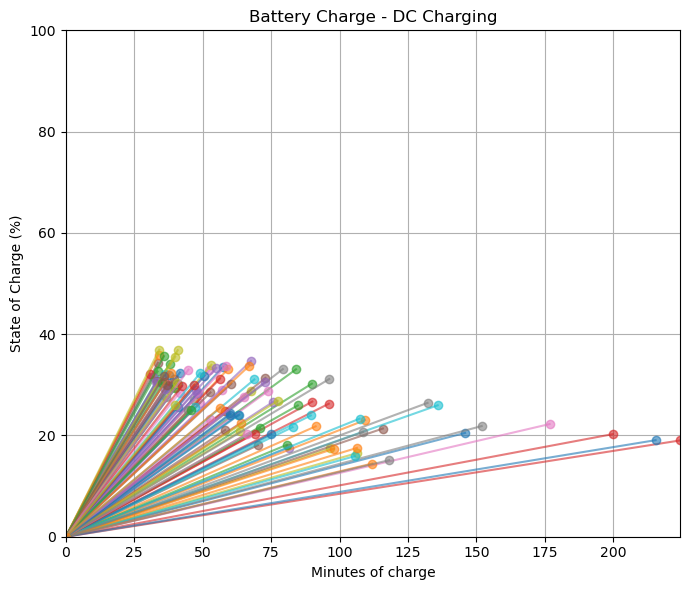

In [30]:
# Visualize delta_soc
charge_data['soc'] = 0
charge_data['end_soc'] = charge_data['soc'] + charge_data['charge'] 


# --- Matplotlib version ---
# Dictionary to map charge_mode to plot title
mode_titles = {
    120: '120',
    240: '240',
    360: 'DC Charging'
}

for mode, title in mode_titles.items():
    # Filter the data for the current charge mode
    filtered_data = charge_data[charge_data['charge_mode'] == mode]

    # Max min for x-axis scaling based on filtered data
    max_minutes = filtered_data['duration_minutes'].max()

    fig, ax = plt.subplots(figsize=(7, 6))

    for _, row in filtered_data.iterrows():
        x_vals = [0, row['duration_minutes']]
        y_vals = [row['soc'], row['end_soc']]
        ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

    ax.set_title(f'Battery Charge - {title}')
    ax.set_xlabel('Minutes of charge')
    ax.set_ylabel('State of Charge (%)')
    ax.set_xlim(0, max_minutes)
    ax.set_ylim(0, 100)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# --- Plotly version ---

for mode, title in mode_titles.items():
    # Filter the data for the current charge mode
    filtered_data = charge_data[charge_data['charge_mode'] == mode]

    # Reset index to ensure a fresh index for each filtered dataframe
    filtered_data = filtered_data.reset_index(drop=True)

    colors = px.colors.qualitative.Plotly
    fig = go.Figure()

    for color_idx, (_, row) in enumerate(filtered_data.iterrows()):
        fig.add_trace(
            go.Scatter(
                x=[0, row['duration_minutes']],
                y=[row['soc'], row['end_soc']],
                mode='lines+markers',
                opacity=0.5,
                line=dict(color=colors[color_idx % len(colors)], width=2),
                marker=dict(size=6),
                name=f"charge {row.name}",
                hovertemplate=(
                    f"charge index: {row.name}<br>"
                    f"SOC start: {row['soc']}%<br>"
                    f"SOC end: {row['end_soc']}%<br>"
                    f"Min of charge: {row['duration_minutes']} min<br>"
                )
            )
        )

    max_minutes = filtered_data['duration_minutes'].max()
    fig.update_xaxes(title_text='Minutes of charge', range=[0, max_minutes])
    fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

    fig.update_layout(
        title=f"Battery Charge - {title}",
        height=500,
        width=700,
        showlegend=False,
        hovermode='closest'
    )
    fig.show()

In [31]:
charge_data['charge_per_min'].describe()

count    561.000000
mean       0.128273
std        0.230366
min        0.008603
25%        0.019854
50%        0.026293
75%        0.069353
max        1.083063
Name: charge_per_min, dtype: float64

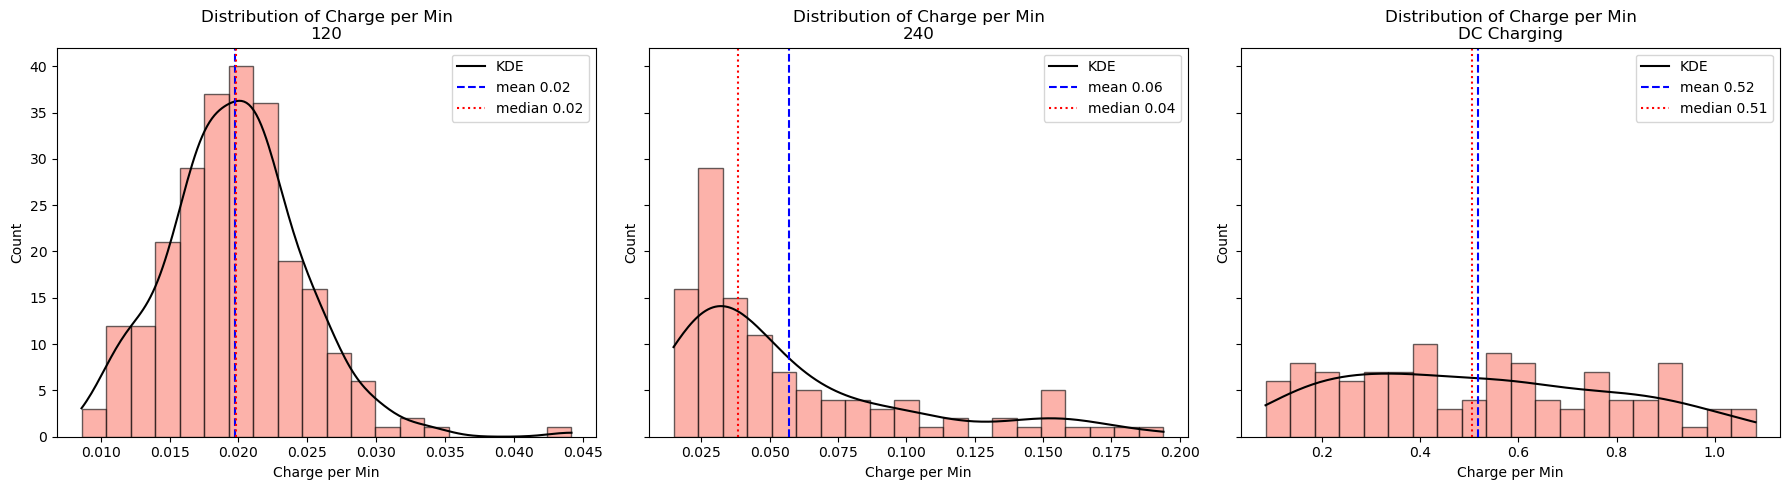

In [32]:
# --- Distribution of Charge per min ---

# Map charge_mode values to labels
charge_labels = {120: "120", 240: "240", 360: "DC Charging"}

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate([120, 240, 360]):
    data_mode = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='salmon',
                       title=f"Distribution of Charge per Min\n{charge_labels[mode]}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()


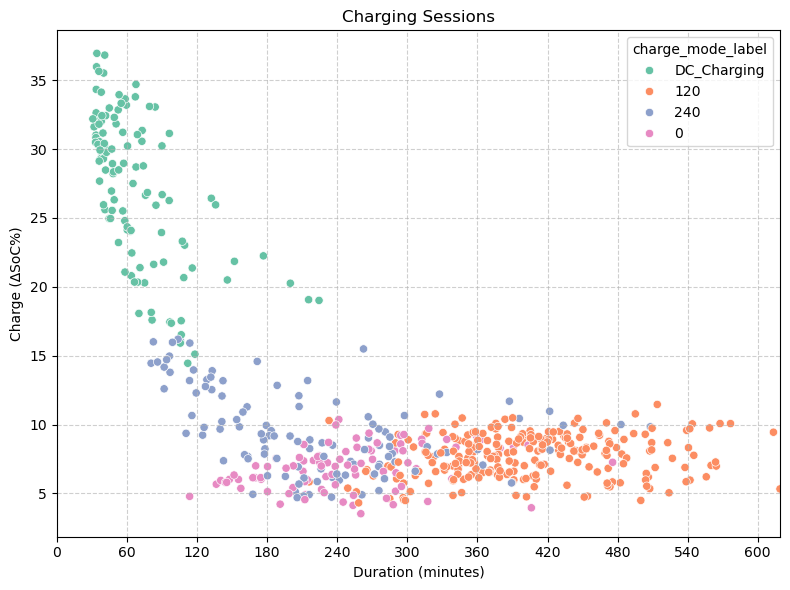

In [33]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker
# Mapping of charge_mode
charge_mode_map = {
    0: "0",
    120: "120",
    240: "240",
    360: "DC_Charging"
}
charge_data = charge_data.copy()
charge_data["charge_mode_label"] = charge_data["charge_mode"].map(charge_mode_map)

max_duration = charge_data["duration_minutes"].max()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    palette="Set2",   # use a default color palette
    legend="auto"
)

plt.title("Charging Sessions")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (∆SoC%)")
plt.grid(True)


# Denser grid on x-axis
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(60))  # every 50 minutes
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [34]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    561 non-null    int64  
 1   charge_mode              561 non-null    int64  
 2   duration_minutes         561 non-null    float64
 3   km_driven                561 non-null    float64
 4   charge                   561 non-null    float64
 5   id                       561 non-null    int64  
 6   delta_soc                561 non-null    float64
 7   min_per_perc_of_battery  561 non-null    float64
 8   charge_per_min           561 non-null    float64
 9   soc                      561 non-null    int64  
 10  end_soc                  561 non-null    float64
 11  charge_mode_label        561 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 52.7+ KB


## Original dataset

In [35]:
charge_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
charge_data_original = charge_data_original[charge_data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          543 non-null    float64
 1   timestamp    543 non-null    object 
 2   end_time     543 non-null    object 
 3   odo          543 non-null    float64
 4   end_odo      543 non-null    float64
 5   soc          543 non-null    float64
 6   end_soc      543 non-null    float64
 7   event        543 non-null    object 
 8   charge_mode  543 non-null    object 
dtypes: float64(5), object(4)
memory usage: 38.3+ KB


In [36]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\n🔋 Statistics on Charge:\n", -charge_data_original['discharge'].describe())

Number of rows after removing duplicates: 516

🔋 Statistics on Charge:
 count   -516.000000
mean      17.133527
std      -13.898268
min       65.100000
25%       29.400000
50%       13.950000
75%        3.175000
max        0.300000
Name: discharge, dtype: float64


In [37]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)


In [38]:
MAX_CHARGE_PER_MIN = 1.10
##########################################################



anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 12


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
0,-2.471740e+18,2021-04-29 10:46:00,2021-04-29 11:17:00,2286.71875,2286.734375,24.3,59.2,charge,DCCharging,-34.9,31.0,0.888252,1.125806
112,-2.471740e+18,2021-06-07 22:55:00,2021-06-07 23:26:00,11661.75000,11661.750000,29.8,65.0,charge,DCCharging,-35.2,31.0,0.880682,1.135484
155,-2.471740e+18,2021-06-19 00:21:00,2021-06-19 00:51:00,15289.43750,15289.437500,29.8,64.3,charge,DCCharging,-34.5,30.0,0.869565,1.150000
223,-2.471740e+18,2021-07-15 20:12:00,2021-07-15 20:27:00,22365.68750,22365.687500,28.2,44.7,charge,DCCharging,-16.5,15.0,0.909091,1.100000
387,-2.471740e+18,2021-08-17 19:52:00,2021-08-17 20:09:00,34609.67188,34609.671880,29.8,50.9,charge,DCCharging,-21.1,17.0,0.805687,1.241176
390,-2.471740e+18,2021-08-18 13:57:00,2021-08-18 14:28:00,34909.48438,34909.484380,37.2,72.5,charge,DCCharging,-35.3,31.0,0.878187,1.138710
391,-2.471740e+18,2021-08-18 21:29:00,2021-08-18 22:04:00,35093.70313,35093.703130,37.2,76.8,charge,DCCharging,-39.6,35.0,0.883838,1.131429
394,-2.471740e+18,2021-08-19 15:57:00,2021-08-19 16:15:00,35501.14063,35501.140630,43.1,63.1,charge,DCCharging,-20.0,18.0,0.900000,1.111111
413,-2.471740e+18,2021-08-25 16:29:00,2021-08-25 16:41:00,37669.50000,37669.500000,30.9,48.6,charge,DCCharging,-17.7,12.0,0.677966,1.475000
453,-2.471740e+18,2021-09-07 01:55:00,2021-09-07 02:40:00,41677.68750,41677.687500,27.4,81.1,charge,DCCharging,-53.7,45.0,0.837989,1.193333


In [39]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      504 non-null    float64       
 1   timestamp                504 non-null    datetime64[ns]
 2   end_time                 504 non-null    datetime64[ns]
 3   odo                      504 non-null    float64       
 4   end_odo                  504 non-null    float64       
 5   soc                      504 non-null    float64       
 6   end_soc                  504 non-null    float64       
 7   event                    504 non-null    object        
 8   charge_mode              504 non-null    object        
 9   discharge                504 non-null    float64       
 10  duration_minutes         504 non-null    float64       
 11  min_per_perc_of_battery  504 non-null    float64       
 12  charge_per_min           504 non-nul

In [40]:
charge_data_original['charge_per_min'].describe()

count    504.000000
mean       0.379533
std        0.440543
min        0.006557
25%        0.019343
50%        0.072727
75%        0.909677
max        1.100000
Name: charge_per_min, dtype: float64

In [41]:
# Print max charge_data_original['charge_per_min'] when '120' is in charge_data_original['charge_mode'], when '240' is in charge_mode and when 'DC' is in chrge_mode
result = charge_data_original.groupby("charge_mode")["charge_per_min"].max()
print(result)

charge_mode
0             1.006667
120           0.040000
240           0.158333
DCCharging    1.100000
Name: charge_per_min, dtype: float64


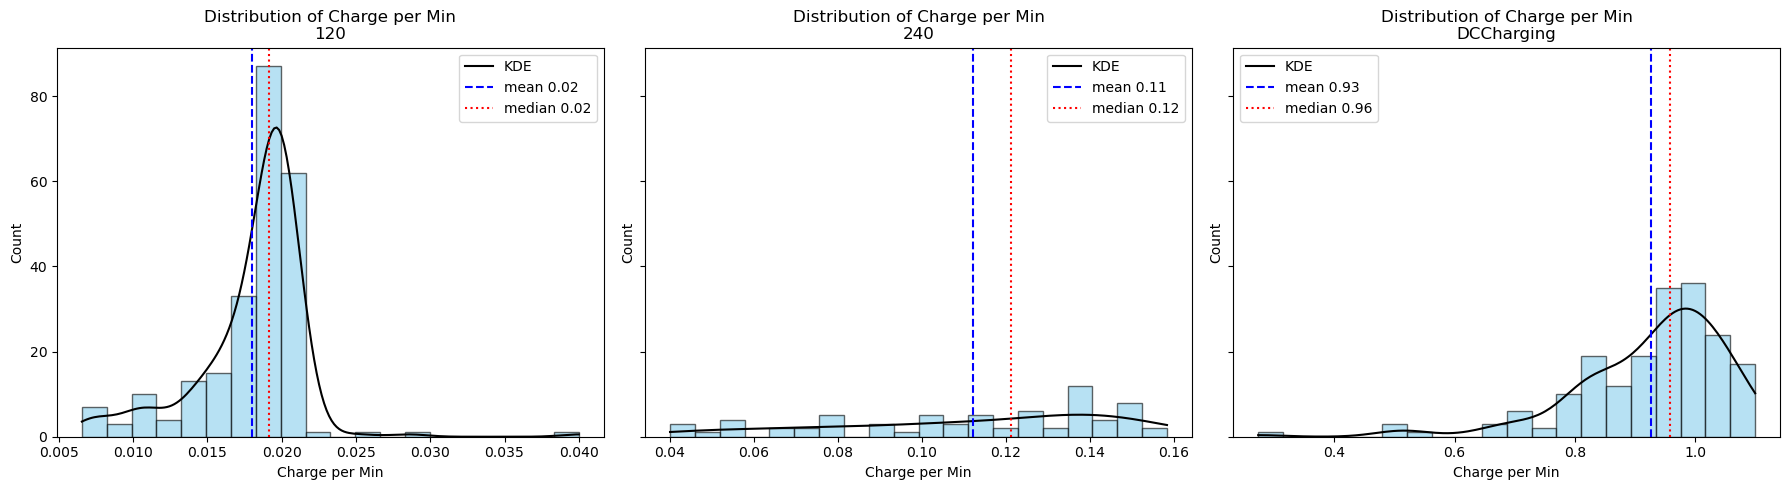

In [42]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()


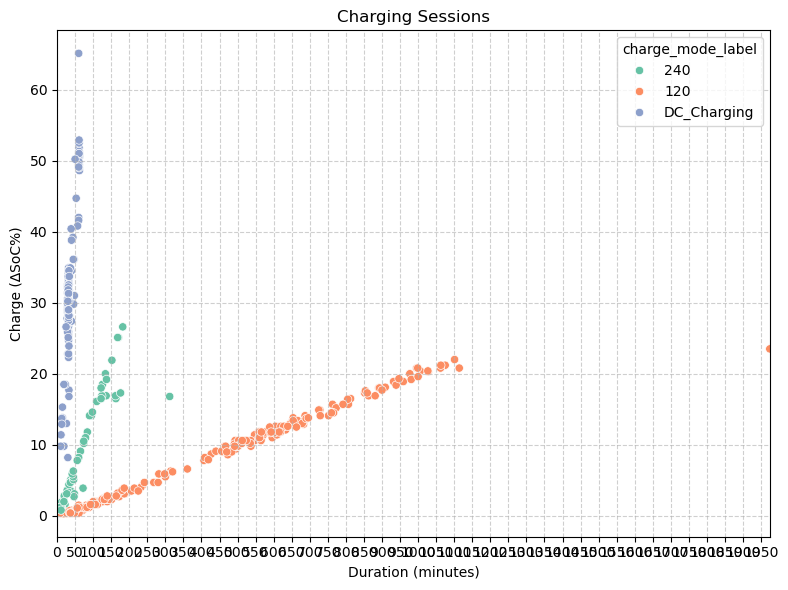

In [43]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker
# Mapping of charge_mode
charge_mode_map = {
    '120': "120",
    '240': "240",
    'DCCharging': "DC_Charging"
}
charge_data_original = charge_data_original.copy()
charge_data_original["charge_mode_label"] = charge_data_original["charge_mode"].map(charge_mode_map)

max_duration = charge_data_original["duration_minutes"].max()
charge_data_original['charge'] = -charge_data_original['discharge']
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data_original,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    palette="Set2",   # use a default color palette
    legend="auto"
)

plt.title("Charging Sessions")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (∆SoC%)")
plt.grid(True)

# Denser grid on x-axis
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(50))  # every 50 minutes
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## Save data

In [44]:
if SAVE:
    # Save DataFrame
    charge_data.to_csv(file_path_csv, index=False)

## Merge

In [45]:
"""# TAKE DATA 
data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')
# print columns
print(data.columns)

# load also trip_Data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/trip_data_cleaned.csv') 

#take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
trip_data = trip_data[['id']]
charge_data_1 = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/charge_data_cleaned.csv')

# take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
charge_data_1 = charge_data_1[[ 'id']]


# keep rows that are present in ids of trip_data and charge_data
data['id'] = data.index

data = data[data['id'].isin(trip_data['id']) | data['id'].isin(charge_data_1['id'])]

#drop columns 'id'
data = data.drop(columns=['id'])

#when event = 1 --> set end_odo = odo 
#data.loc[data['event'] == 1, 'end_odo'] = data['odo']
data.loc[data['event'] == 1, 'km_driven'] = 0

'''# add in first position column 'vin', all rows with value -2.47174E+18
data.insert(0, 'vin', -2.47174E+18)'''

# map event 0 -> trip, 1 -> charge
data['event'] = data['event'].map({0: 'trip', 1: 'charge'})

'''# map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})'''
data.to_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data_cleaned.csv', index=False)"""

"# TAKE DATA \ndata = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')\n# print columns\nprint(data.columns)\n\n# load also trip_Data and charge_data and then filter data, keeping only rows present in trip_data and charge_data\ntrip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/trip_data_cleaned.csv') \n\n#take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'\ntrip_data = trip_data[['id']]\ncharge_data_1 = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/charge_data_cleaned.csv')\n\n# take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'\ncharge_data_1 = charge_data_1[[ 'id']]\n\n\n# keep rows that are present in ids of trip_data and charge_data\ndata['id'] = data.index\n\ndata = data[data['id'].isin(trip_data['id']) | data['id'].isin(charge_data_1['id'])]\n\n#drop columns 'id'\ndata = data.drop(c

In [46]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    561 non-null    int64  
 1   charge_mode              561 non-null    int64  
 2   duration_minutes         561 non-null    float64
 3   km_driven                561 non-null    float64
 4   charge                   561 non-null    float64
 5   id                       561 non-null    int64  
 6   delta_soc                561 non-null    float64
 7   min_per_perc_of_battery  561 non-null    float64
 8   charge_per_min           561 non-null    float64
 9   soc                      561 non-null    int64  
 10  end_soc                  561 non-null    float64
 11  charge_mode_label        561 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 52.7+ KB
